In [4]:
import pandas as pd

df = pd.read_excel("financial_fraud_dataset.xlsx")

In [5]:
df.head

<bound method NDFrame.head of      customer_id transaction_id  transaction_amount transaction_type  \
0          C1000          T1000                2632       NetBanking   
1          C1001          T1001                8524              ATM   
2          C1002          T1002              123080              UPI   
3          C1003          T1003               51853       NetBanking   
4          C1004          T1004              106710       NetBanking   
...          ...            ...                 ...              ...   
9995      C10995         T10995               15803              UPI   
9996      C10996         T10996                8923             Card   
9997      C10997         T10997              118095             Card   
9998      C10998         T10998               77851             Card   
9999      C10999         T10999              131620             Card   

         transaction_time merchant_category  customer_age customer_location  \
0     2026-06-18 23:08:00 

In [6]:
df.tail

<bound method NDFrame.tail of      customer_id transaction_id  transaction_amount transaction_type  \
0          C1000          T1000                2632       NetBanking   
1          C1001          T1001                8524              ATM   
2          C1002          T1002              123080              UPI   
3          C1003          T1003               51853       NetBanking   
4          C1004          T1004              106710       NetBanking   
...          ...            ...                 ...              ...   
9995      C10995         T10995               15803              UPI   
9996      C10996         T10996                8923             Card   
9997      C10997         T10997              118095             Card   
9998      C10998         T10998               77851             Card   
9999      C10999         T10999              131620             Card   

         transaction_time merchant_category  customer_age customer_location  \
0     2026-06-18 23:08:00 

In [7]:
print(df.dtypes)

customer_id                   object
transaction_id                object
transaction_amount             int64
transaction_type              object
transaction_time              object
merchant_category             object
customer_age                   int64
customer_location             object
account_tenure                 int64
device_type                   object
is_foreign_transaction         int64
is_high_risk_country           int64
transaction_frequency_24hr     int64
avg_transaction_amount_7d      int64
failed_login_attempts          int64
card_present                   int64
is_night_transaction           int64
is_fraud                       int64
dtype: object


In [8]:
df['is_fraud'].value_counts()

is_fraud
0    9199
1     801
Name: count, dtype: int64

In [10]:
df.groupby('is_fraud')['transaction_amount'].mean()

is_fraud
0    73588.858245
1    99408.372035
Name: transaction_amount, dtype: float64

In [11]:
df.groupby('is_foreign_transaction')['is_fraud'].mean() #Foreign transactions show higher fraud rate

is_foreign_transaction
0    0.000000
1    0.157833
Name: is_fraud, dtype: float64

In [12]:
df.groupby('is_night_transaction')['is_fraud'].mean()

is_night_transaction
0    0.000000
1    0.323898
Name: is_fraud, dtype: float64

In [13]:
df.groupby('is_fraud')['transaction_frequency_24hr'].mean()

is_fraud
0    8.024242
1    7.892634
Name: transaction_frequency_24hr, dtype: float64

In [19]:
import sklearn
print("Installed successfully")

Installed successfully


In [21]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

df = pd.read_excel("financial_fraud_dataset.xlsx")

X = df[['transaction_amount','is_foreign_transaction','is_high_risk_country',
        'transaction_frequency_24hr','avg_transaction_amount_7d',
        'failed_login_attempts','card_present','is_night_transaction']]

y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9965
[[1829    0]
 [   7  164]]


In [25]:
import pandas as pd

new_transaction = pd.DataFrame([[80000, 1, 1, 10, 20000, 2, 0, 1]],
    columns=['transaction_amount','is_foreign_transaction','is_high_risk_country',
             'transaction_frequency_24hr','avg_transaction_amount_7d',
             'failed_login_attempts','card_present','is_night_transaction'])

prediction = model.predict(new_transaction)

if prediction[0] == 1:
    print("Fraud Transaction 🚨")
else:
    print("Normal Transaction ✅")

Fraud Transaction 🚨


In [27]:
import pandas as pd

new_transaction = pd.DataFrame([[1000, 0, 0, 2, 1200, 0, 1, 0]],
    columns=['transaction_amount','is_foreign_transaction','is_high_risk_country',
             'transaction_frequency_24hr','avg_transaction_amount_7d',
             'failed_login_attempts','card_present','is_night_transaction'])

prediction = model.predict(new_transaction)

if prediction[0] == 1:
    print("Fraud Transaction 🚨")
else:
    print("Normal Transaction ✅")

Normal Transaction ✅


In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

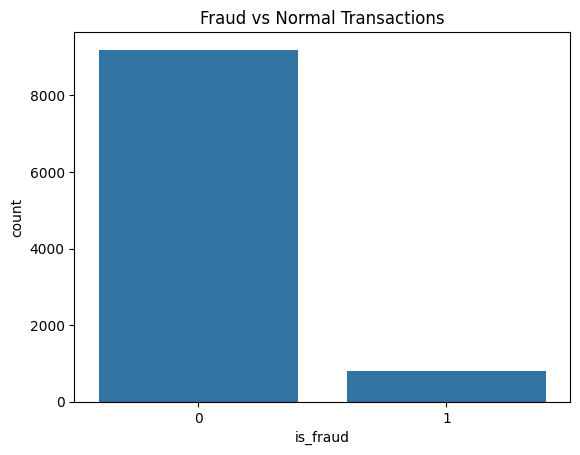

In [30]:
sns.countplot(x='is_fraud', data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()


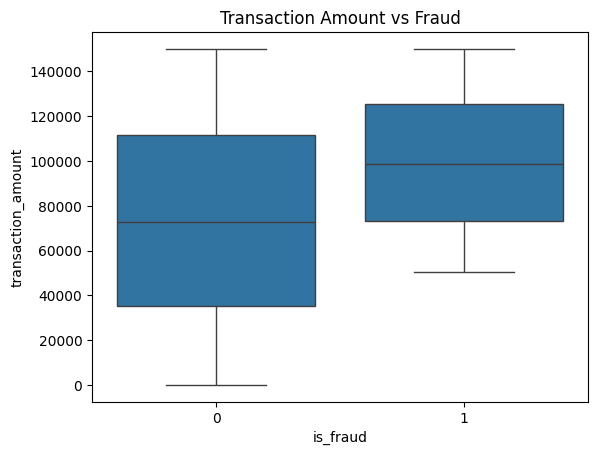

In [31]:
sns.boxplot(x='is_fraud', y='transaction_amount', data=df)
plt.title("Transaction Amount vs Fraud")
plt.show()

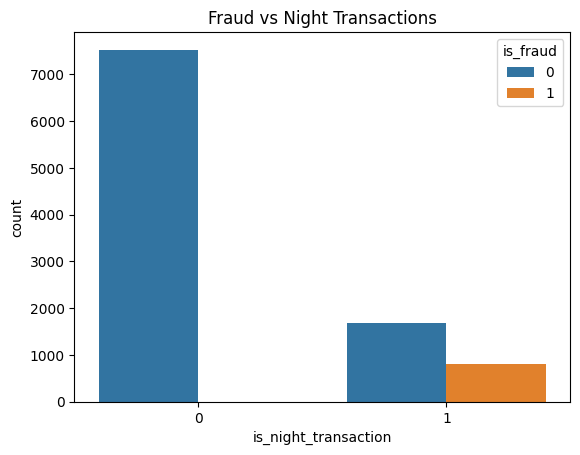

In [32]:
sns.countplot(x='is_night_transaction', hue='is_fraud', data=df)
plt.title("Fraud vs Night Transactions")
plt.show()


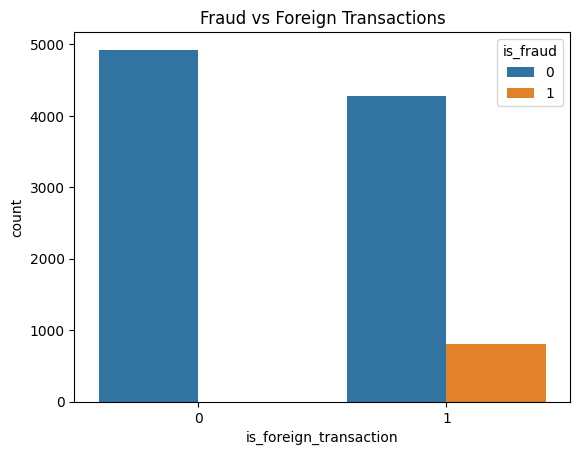

In [33]:
sns.countplot(x='is_foreign_transaction', hue='is_fraud', data=df)
plt.title("Fraud vs Foreign Transactions")
plt.show()
#Fraud transactions are significantly higher for foreign transactions